# FIFA World Cup 2026 — Host City Airport Operations Analysis

This notebook provides a comparative analysis of airport traffic across all **16 FIFA 2026 host cities** (3 in Mexico, 11 in the USA, 2 in Canada). The goal is to understand current air capacity, international connectivity, historical growth trends, and potential congestion risk during the tournament (June–July 2026).

## Host Cities
| Country | Cities |
|---------|--------|
| 🇲🇽 Mexico | Mexico City, Guadalajara, Monterrey |
| 🇺🇸 USA | Atlanta, Boston, Dallas, Houston, Kansas City, Los Angeles, Miami, New York/NJ, Philadelphia, San Francisco, Seattle |
| 🇨🇦 Canada | Toronto, Vancouver |

## Key Design Decision — New Jersey / New York
MetLife Stadium is in East Rutherford, NJ. The full **NYC Metro area** (EWR + JFK + LGA) is used since fans flying into the region would use any of the three airports (~8–25 miles from the stadium). This gives the most accurate picture of air access capacity.

## Data Sources
| Source | Coverage | Scope |
|--------|----------|-------|
| US BTS T100 Segment Summary | 2014–2026 | Passengers, flights, load factor, domestic/intl split |
| Mexico SASE (AFAC/SCT) | 2021–2026 (Apr) | O-D pairs, passengers & flights, domestic & international |
| Statistics Canada 23100253 | 2008–2024 | Passengers enplaned/deplaned by airport & sector |

In [69]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import openpyxl
from collections import defaultdict
from pathlib import Path

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

BASE = Path('cities/airport_flows')
print('Environment ready')

Environment ready


---
## 1. City & Airport Reference Table

In [70]:
# --- Stadium / city reference from data_fifa.xlsx ---
wb = openpyxl.load_workbook('data_fifa.xlsx', read_only=True)
ws = wb['stadiums']
rows = list(ws.iter_rows(values_only=True))
stadiums_df = pd.DataFrame(rows[1:], columns=rows[0]).dropna(subset=['city'])

# Airport mapping per city (IATA codes for US, city names for Mexico, GEO strings for Canada)
CITY_AIRPORTS_US = {
    'New Jersey':    ['EWR', 'JFK', 'LGA'],   # NYC Metro — all 3 serve MetLife catchment
    'Atlanta':       ['ATL'],
    'Boston':        ['BOS'],
    'Dallas':        ['DFW', 'DAL'],
    'Houston':       ['IAH', 'HOU'],
    'Kansas City':   ['MCI'],
    'Los Angeles':   ['LAX'],
    'Miami':         ['MIA'],
    'Philadelphia':  ['PHL'],
    'San Francisco': ['SFO'],
    'Seattle':       ['SEA'],
}

# Mexico SASE city names (as they appear in ORIGEN column)
CITY_AIRPORTS_MX = {
    'Mexico City':  ['MEXICO', 'SANTA LUCÍA'],  # MEX (Benito Juárez) + AIFA (Felipe Angeles, from 2022)
    'Guadalajara':  ['GUADALAJARA'],
    'Monterrey':    ['MONTERREY'],
}

# Canada Statistics Canada GEO substrings
CITY_AIRPORTS_CA = {
    'Toronto':   ['Toronto/Lester B Pearson International'],
    'Vancouver': ['Vancouver International'],
}

# Display stadium reference
stadiums_df[['city','stadium','country','capacity']].style \
    .background_gradient(subset=['capacity'], cmap='YlOrRd') \
    .format({'capacity': '{:,.0f}'}) \
    .set_caption('FIFA 2026 Stadiums')

,city,stadium,country,capacity
0,Mexico City,Estadio Azteca,MEX,"83,000"
1,Guadalajara,Estadio Guadalajara,MEX,"48,000"
2,Monterrey,Estadio Monterrey,MEX,"53,500"
3,Houston,NRG Stadium,USA,"72,000"
4,Dallas,AT&T Stadium,USA,"94,000"
5,Kansas City,Arrowhead Stadium,USA,"73,000"
6,Atlanta,Mercedes-Benz Stadium,USA,"75,000"
7,Miami,Hard Rock Stadium,USA,"65,000"
8,Los Angeles,SoFi Stadium,USA,"70,000"
9,San Francisco,San Francisco Bay Area Stadium,USA,"71,000"


---
## 2. Load & Parse All Datasets

In [71]:
# ============================================================
# 2A. US — BTS T100 Segment Summary (2014–2026)
# ============================================================
t100 = pd.read_csv(BASE / 'US/AFF_-_T100_Segment_Summary_By_Origin_Airport_20260527.csv')

# Comma-formatted number columns
str_cols = [
    'Total Departures', 'Total Passengers', 'Total Seats',
    'Domestic Departures', 'Domestic Passengers', 'Domestic Seats',
    'Outbound International Departures', 'Outbound International Passengers', 'Outbound International Seats',
    'Inbound International Departures', 'Inbound International Passengers', 'Inbound International Seats',
]
for c in str_cols:
    t100[c] = t100[c].astype(str).str.replace(',', '').pipe(pd.to_numeric, errors='coerce')

# Drop partial 2026 and keep clean annual rows
t100_annual = t100[~t100['Year'].str.contains('M', na=False)].copy()
t100_annual['Year'] = t100_annual['Year'].astype(int)

def us_city_agg(df, year_filter=None):
    """Aggregate T100 by FIFA city label."""
    d = df if year_filter is None else df[df['Year'].isin(year_filter)]
    records = []
    for city, codes in CITY_AIRPORTS_US.items():
        sub = d[d['Origin Airport Code'].isin(codes)]
        for yr, g in sub.groupby('Year'):
            records.append({
                'city': city, 'country': 'USA', 'year': yr,
                'total_pax':     g['Total Passengers'].sum(),
                'total_flights': g['Total Departures'].sum(),
                'intl_pax':      g['Outbound International Passengers'].sum(),
                'dom_pax':       g['Domestic Passengers'].sum(),
                'total_seats':   g['Total Seats'].sum(),
                'load_factor':   g['Total Load Factor (%)'].mean(),
            })
    return pd.DataFrame(records)

us_df = us_city_agg(t100_annual)
print(f'US data: {len(us_df)} city-year records, years {us_df.year.min()}–{us_df.year.max()}')

US data: 132 city-year records, years 2014–2025


In [72]:
# ============================================================
# 2B. Mexico — SASE AFAC files (2021–2026)
# ============================================================
MX_FILES = {
    2021: BASE / 'Mexico/sase-diciembre-2021-24042025.xlsx',
    2022: BASE / 'Mexico/sase-diciembre-2022-28012026.xlsx',
    2023: BASE / 'Mexico/sase-diciembre-2023-28012026.xlsx',
    2024: BASE / 'Mexico/sase-diciembre-2024-28012026.xlsx',
    2025: BASE / 'Mexico/sase-diciembre-2025-05022026h.xlsx',
    2026: BASE / 'Mexico/sase-abril-2026-27052026.xlsx',  # Jan–Apr only
}

MX_MONTHS = 12  # NAT and INT sheets: months Jan-Dec

def parse_sase_sheet(ws, sheet_type='NAC'):
    """
    Returns dict: city -> {pax, flights} summed over all months.
    NAC: col0=ORIGEN, col1=DESTINO, cols2:14=monthly flights, cols15:27=monthly pax
    INT: col0=ORIGEN, col1=PAIS_ORIGEN, col2=DESTINO, col3=PAIS_DESTINO,
         cols4:16=monthly flights, cols17:29=monthly pax
    """
    rows = list(ws.iter_rows(values_only=True))
    city_pax = defaultdict(float)
    city_flt = defaultdict(float)

    if sheet_type == 'NAC':
        origin_col, flt_start, pax_start = 0, 2, 15
        country_filter = None
    else:  # INT
        origin_col, country_col = 0, 1
        flt_start, pax_start = 4, 17
        country_filter = 'Mexico'

    for r in rows[6:]:
        orig = r[origin_col] if r[origin_col] else None
        if orig is None:
            continue
        orig = str(orig).strip()
        if country_filter and (r[country_col] is None or str(r[country_col]).strip() != country_filter):
            continue
        # Sum numeric values only (skip Excel formula strings)
        flt_vals = [v for v in r[flt_start:flt_start+12] if isinstance(v, (int, float))]
        pax_vals = [v for v in r[pax_start:pax_start+12] if isinstance(v, (int, float))]
        city_flt[orig] += sum(flt_vals)
        city_pax[orig] += sum(pax_vals)

    return city_pax, city_flt

mx_records = []
for yr, fpath in MX_FILES.items():
    wb_mx = openpyxl.load_workbook(fpath, read_only=True)
    nac_pax, nac_flt = parse_sase_sheet(wb_mx['REG NAC'], 'NAC')
    int_pax, int_flt = parse_sase_sheet(wb_mx['REG INT'], 'INT')

    for city_label, sase_names in CITY_AIRPORTS_MX.items():
        tp = sum(nac_pax[n] + int_pax[n] for n in sase_names)
        tf = sum(nac_flt[n] + int_flt[n] for n in sase_names)
        ip = sum(int_pax[n] for n in sase_names)
        dp = sum(nac_pax[n] for n in sase_names)
        mx_records.append({
            'city': city_label, 'country': 'Mexico', 'year': yr,
            'total_pax': tp, 'total_flights': tf,
            'intl_pax': ip, 'dom_pax': dp,
            'total_seats': np.nan, 'load_factor': np.nan,
            'is_partial': yr == 2026,
        })

mx_df = pd.DataFrame(mx_records)
mx_df['is_partial'] = mx_df.get('is_partial', False).fillna(False)
print(f'Mexico data: {len(mx_df)} city-year records')
mx_df[mx_df['year']==2025][['city','total_pax','intl_pax','dom_pax']]

Mexico data: 18 city-year records


,city,total_pax,intl_pax,dom_pax
12,Mexico City,25199261.0,8688211.0,16511050.0
13,Guadalajara,9244613.0,2860186.0,6384427.0
14,Monterrey,7643752.0,1190960.0,6452792.0


In [73]:
# ============================================================
# 2C. Canada — Statistics Canada 23100253 (2008–2024)
# ============================================================
ca_raw = pd.read_csv(BASE / 'Canada/23100253.csv')
ca_raw['VALUE'] = pd.to_numeric(ca_raw['VALUE'], errors='coerce')

ca_records = []
for city_label, geo_list in CITY_AIRPORTS_CA.items():
    for geo_str in geo_list:
        sub = ca_raw[ca_raw['GEO'].str.contains(geo_str, case=False, na=False)]
        for yr, g in sub.groupby('REF_DATE'):
            def _val(metric):
                v = g[g['Air passenger traffic']==metric]['VALUE']
                return v.iloc[0] if len(v) else np.nan
            total   = _val('Total, passengers enplaned and deplaned')
            enplane = _val('Passengers enplaned')
            dom     = _val('Domestic sector')
            transb  = _val('Transborder sector')   # US traffic
            other_intl = _val('Other International sector')
            intl    = (transb if not np.isnan(transb) else 0) + (other_intl if not np.isnan(other_intl) else 0)
            ca_records.append({
                'city': city_label, 'country': 'Canada', 'year': int(yr),
                'total_pax': total, 'total_flights': np.nan,
                'intl_pax': intl, 'dom_pax': dom,
                'total_seats': np.nan, 'load_factor': np.nan,
            })

ca_df = pd.DataFrame(ca_records)
print(f'Canada data: {len(ca_df)} city-year records, years {ca_df.year.min()}–{ca_df.year.max()}')
ca_df[ca_df['year']==2024][['city','total_pax','intl_pax','dom_pax']]

Canada data: 34 city-year records, years 2008–2024


,city,total_pax,intl_pax,dom_pax
16,Toronto,45714326.0,29738307.0,15976019.0
33,Vancouver,25294940.0,12921667.0,12373273.0


In [74]:
# ============================================================
# Combine all three into one master DataFrame
# ============================================================
# Mexico 2026 is Jan–Apr partial; mark it
if 'is_partial' not in us_df.columns:
    us_df['is_partial'] = False
if 'is_partial' not in ca_df.columns:
    ca_df['is_partial'] = False

all_df = pd.concat([us_df, mx_df, ca_df], ignore_index=True)
all_df['intl_share'] = all_df['intl_pax'] / all_df['total_pax']

# City ordering (South to North roughly, then by volume)
COUNTRY_ORDER = {'Mexico': 0, 'USA': 1, 'Canada': 2}
all_df['country_order'] = all_df['country'].map(COUNTRY_ORDER)

print(f'Combined: {len(all_df)} city-year records across {all_df["city"].nunique()} cities')
all_df.groupby('country')['city'].unique()

Combined: 184 city-year records across 16 cities


country
Canada                                 [Toronto, Vancouver]
Mexico                [Mexico City, Guadalajara, Monterrey]
USA       [New Jersey, Atlanta, Boston, Dallas, Houston,...
Name: city, dtype: object

---
## 3. 2024 Snapshot — Total Passengers & International Share

Most recent complete year available for all three countries.

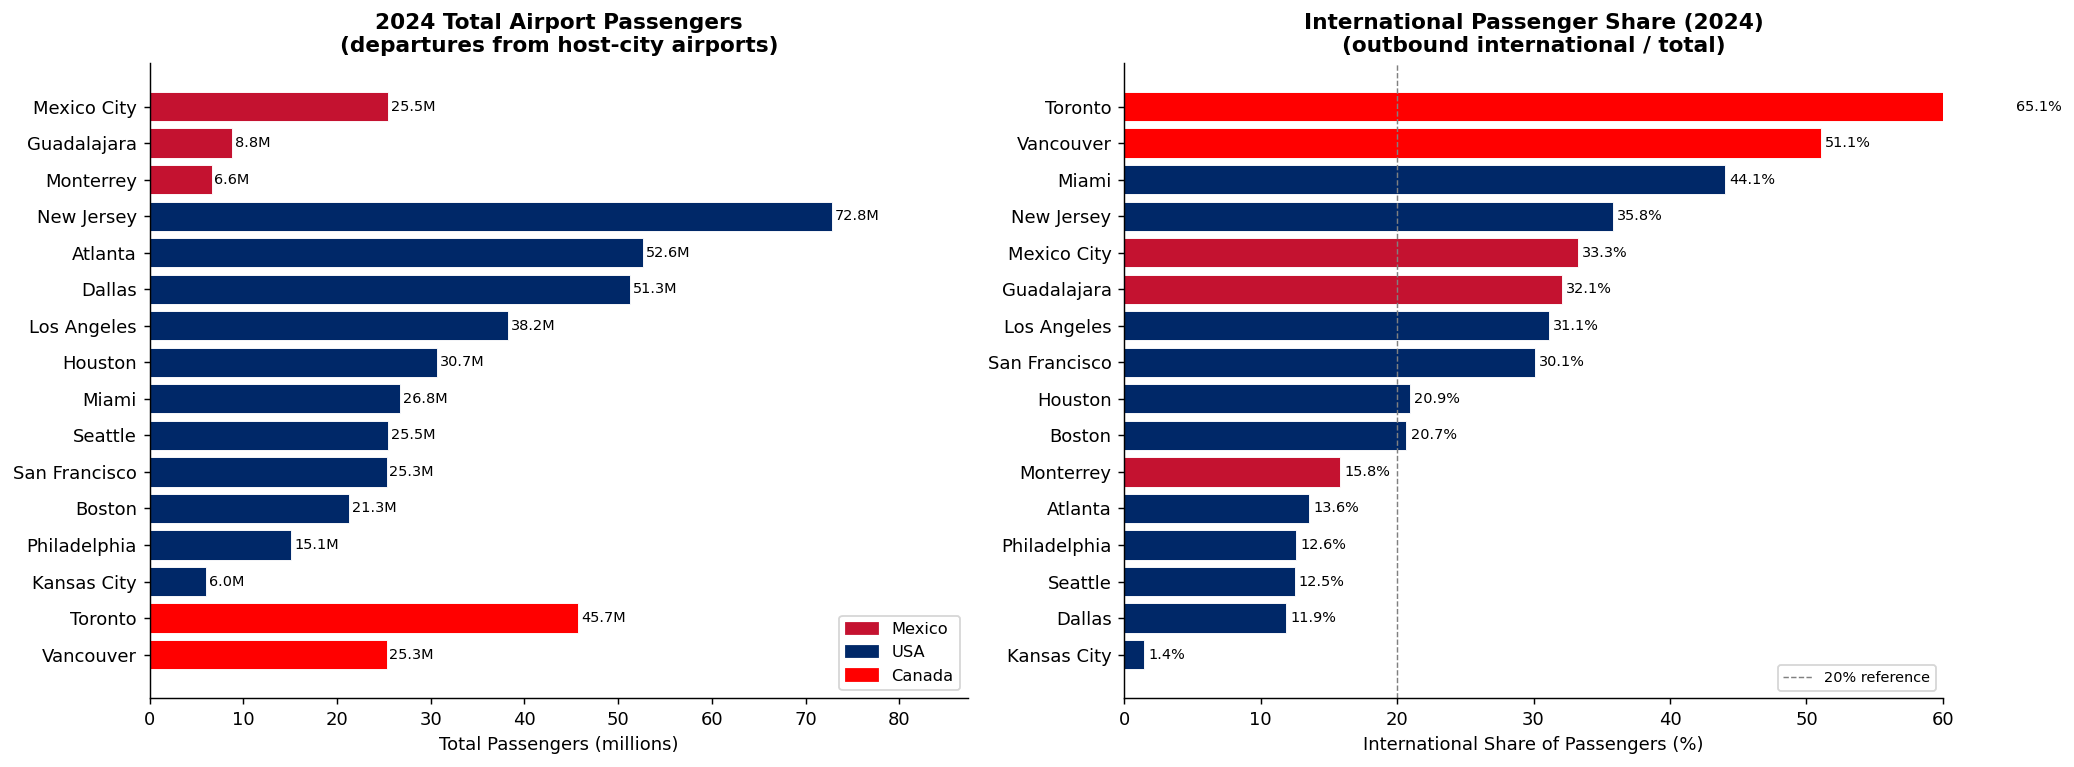

Note: Canada intl_share includes transborder (US) + other international.
Note: Mexico intl_share = scheduled international departures / (domestic + international).


In [75]:
snap = all_df[all_df['year']==2024].copy()
snap = snap.sort_values(['country_order','total_pax'], ascending=[True, False])

colors = {'Mexico': '#C41230', 'USA': '#002868', 'Canada': '#FF0000'}
bar_colors = snap['country'].map(colors)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Total Passengers ---
ax = axes[0]
bars = ax.barh(snap['city'], snap['total_pax'] / 1e6, color=bar_colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Total Passengers (millions)', fontsize=10)
ax.set_title('2024 Total Airport Passengers\n(departures from host-city airports)', fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, snap['total_pax']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val/1e6:.1f}M', va='center', fontsize=8)
ax.set_xlim(0, snap['total_pax'].max()/1e6 * 1.2)

# Legend
patches = [mpatches.Patch(color=v, label=k) for k, v in colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=9)

# --- Right: International Share ---
ax2 = axes[1]
snap_intl = snap.dropna(subset=['intl_share']).sort_values('intl_share', ascending=True)
bar2 = ax2.barh(snap_intl['city'], snap_intl['intl_share'] * 100,
                color=snap_intl['country'].map(colors), edgecolor='white', linewidth=0.5)
ax2.axvline(x=20, color='gray', linestyle='--', linewidth=0.8, label='20% reference')
ax2.set_xlabel('International Share of Passengers (%)', fontsize=10)
ax2.set_title('International Passenger Share (2024)\n(outbound international / total)', fontweight='bold')
for bar, val in zip(bar2, snap_intl['intl_share']):
    ax2.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val*100:.1f}%', va='center', fontsize=8)
ax2.set_xlim(0, 60)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('2024_snapshot.png', bbox_inches='tight', dpi=150)
plt.show()
print('Note: Canada intl_share includes transborder (US) + other international.')
print('Note: Mexico intl_share = scheduled international departures / (domestic + international).')

In [76]:
# Summary table for 2024
snap_table = snap[['city','country','total_pax','dom_pax','intl_pax','total_flights','load_factor']].copy()
snap_table = snap_table.sort_values('total_pax', ascending=False).reset_index(drop=True)
snap_table.index += 1
snap_table['intl_share_%'] = (snap_table['intl_pax'] / snap_table['total_pax'] * 100).round(1)

snap_table.style \
    .format({
        'total_pax': '{:,.0f}', 'dom_pax': '{:,.0f}', 'intl_pax': '{:,.0f}',
        'total_flights': '{:,.0f}', 'load_factor': '{:.1f}%', 'intl_share_%': '{:.1f}%'
    }) \
    .background_gradient(subset=['total_pax'], cmap='Blues') \
    .background_gradient(subset=['intl_share_%'], cmap='Greens') \
    .set_caption('2024 Airport Operations — All FIFA 2026 Host Cities')

,city,country,total_pax,dom_pax,intl_pax,total_flights,load_factor,intl_share_%
1,New Jersey,USA,"72,789,612","46,720,260","26,069,352","594,554",83.7%,35.8%
2,Atlanta,USA,"52,616,638","45,479,185","7,137,453","387,361",84.5%,13.6%
3,Dallas,USA,"51,260,498","45,184,796","6,075,702","437,645",80.2%,11.9%
4,Toronto,Canada,"45,714,326","15,976,019","29,738,307",nan,nan%,65.1%
5,Los Angeles,USA,"38,240,898","26,342,946","11,897,952","274,433",84.2%,31.1%
6,Houston,USA,"30,671,677","24,252,477","6,419,200","276,530",79.2%,20.9%
7,Miami,USA,"26,762,659","14,970,573","11,792,086","217,293",83.0%,44.1%
8,Mexico City,Mexico,"25,491,684","17,011,618","8,480,066","178,901",nan%,33.3%
9,Seattle,USA,"25,467,226","22,288,469","3,178,757","213,502",83.3%,12.5%
10,San Francisco,USA,"25,301,322","17,681,691","7,619,631","177,596",83.2%,30.1%


---
## 4. Multi-Year Traffic Trends

We track total departing passengers from **2019 (pre-COVID baseline) through 2025**. Where data starts later (Mexico: 2021, Canada: full history), we align accordingly.

This section illustrates:
- The **COVID-19 shock** (2020–2021) and the speed of recovery
- **Growth trajectories** — which cities are expanding fastest heading into 2026

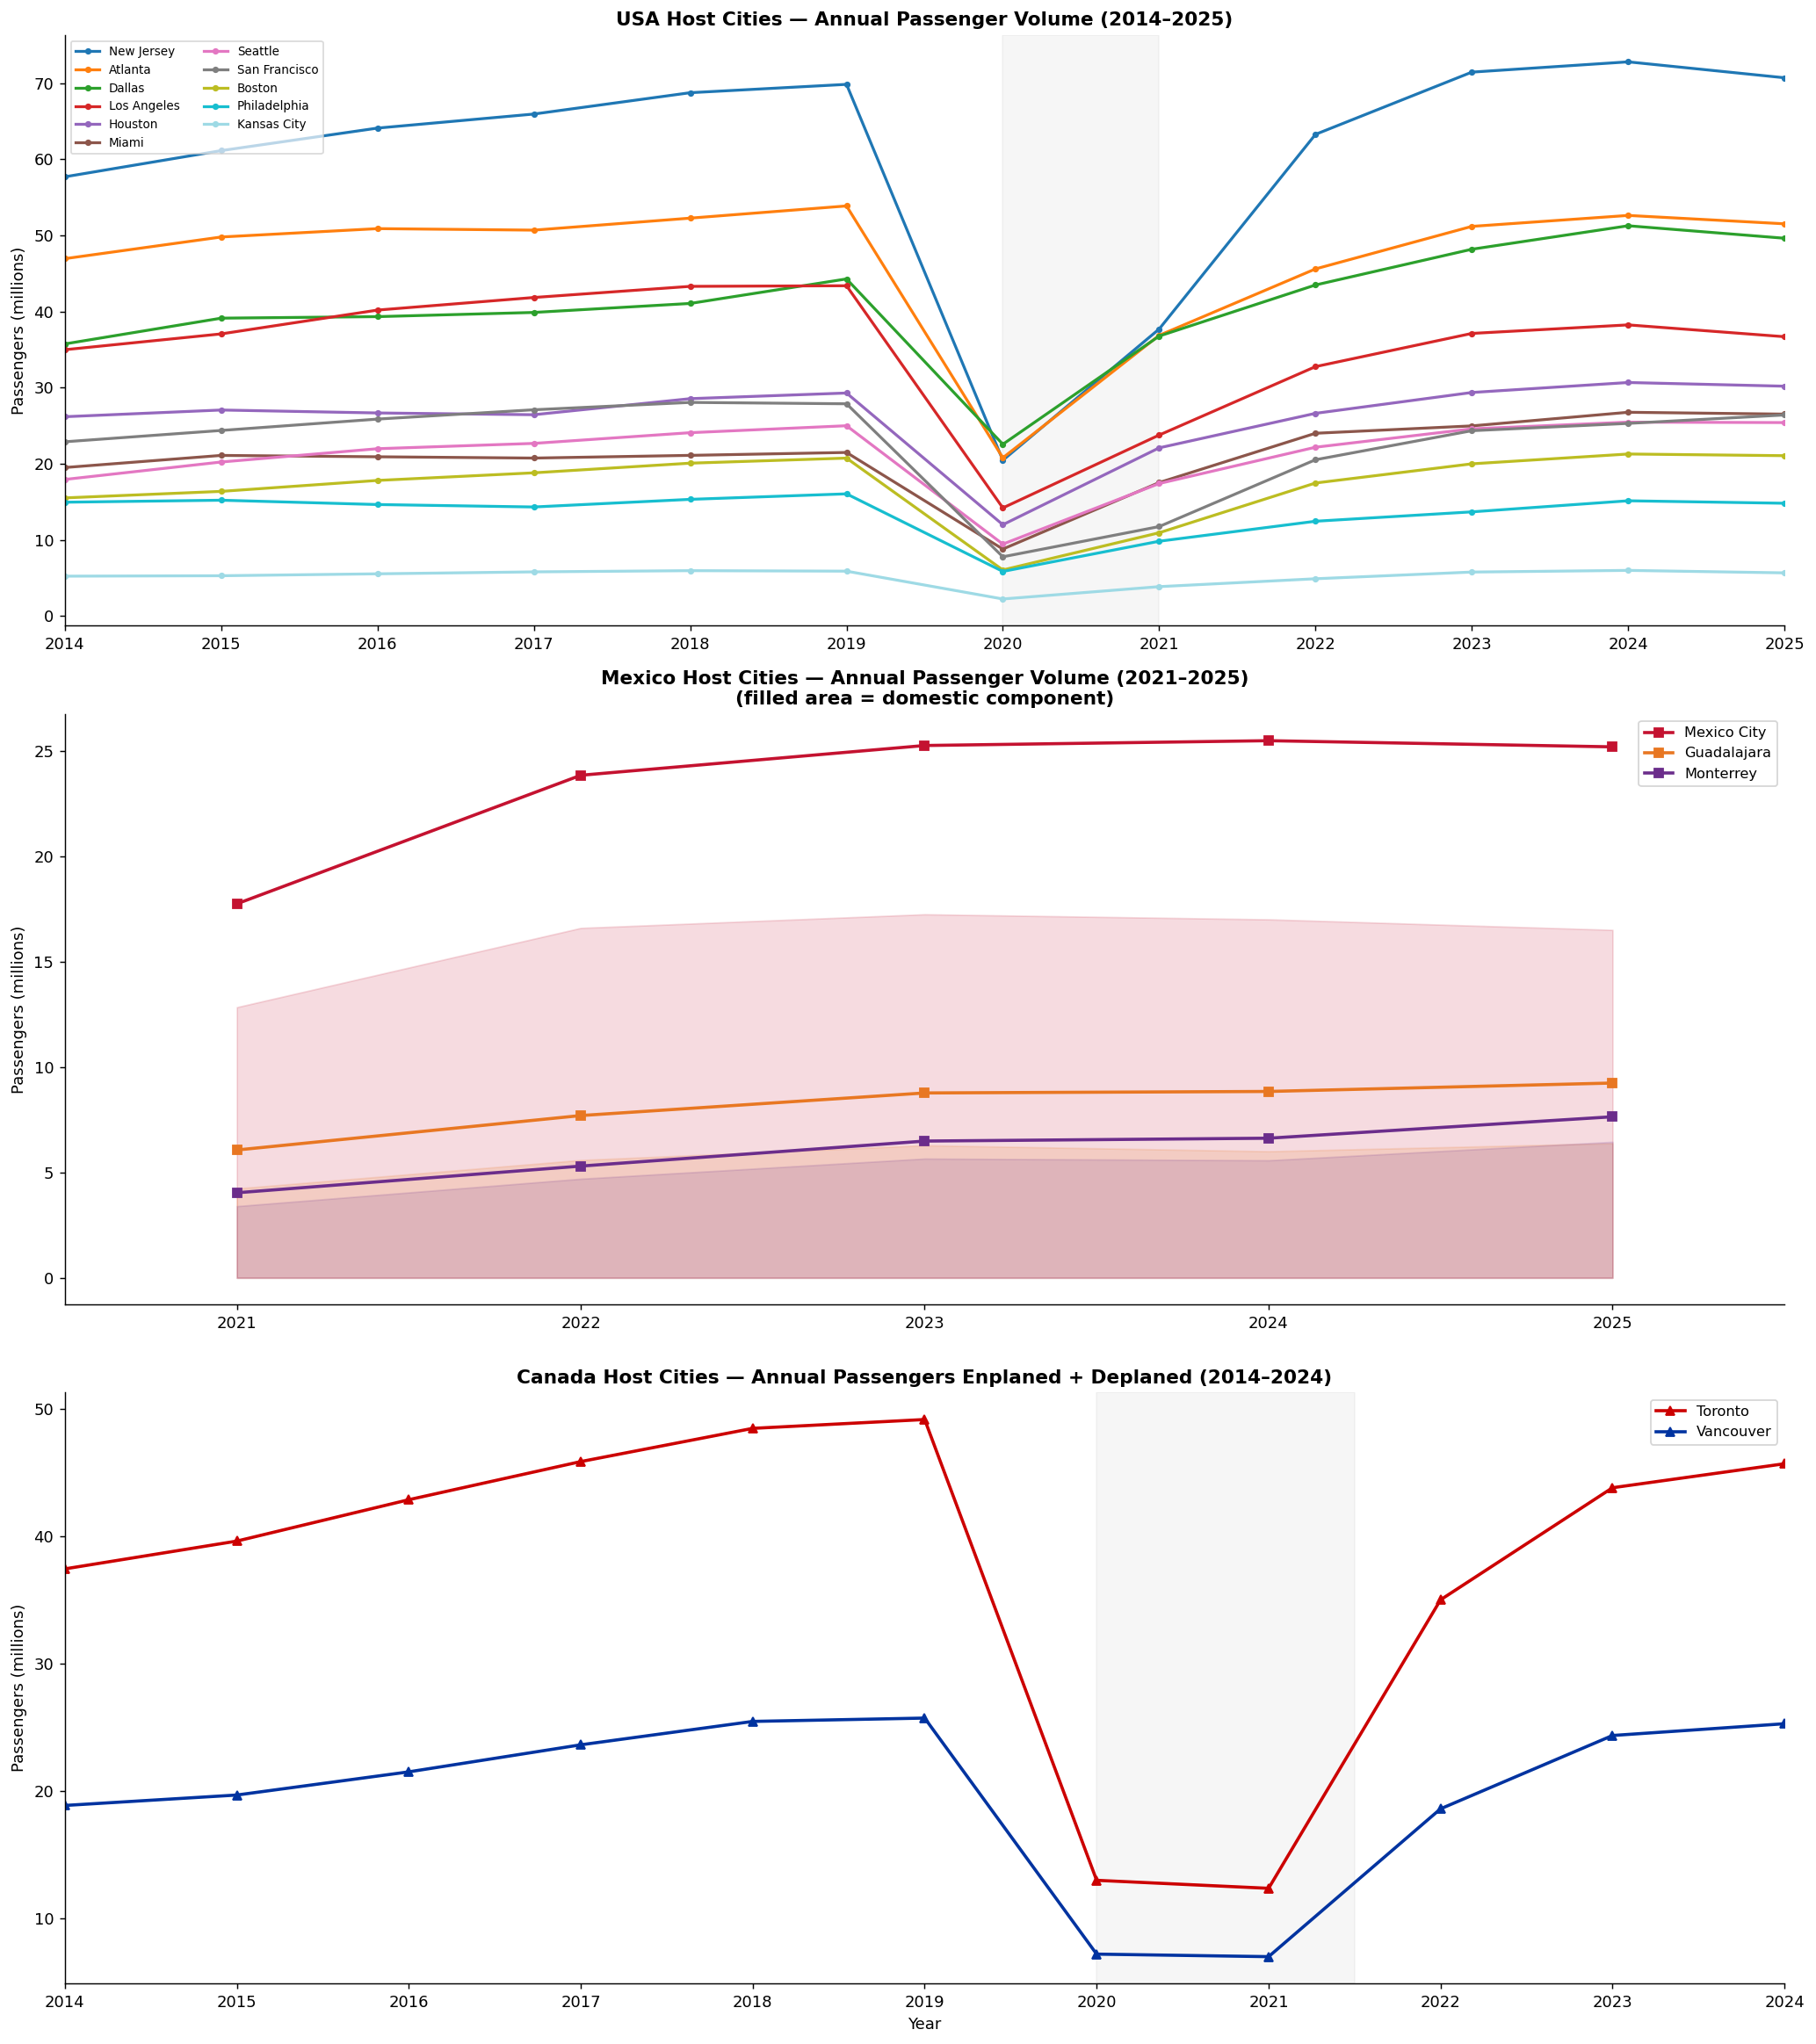

In [77]:
fig, axes = plt.subplots(3, 1, figsize=(16, 18))
trend_years = list(range(2014, 2026))

# ---- USA ----
ax = axes[0]
us_trend = us_df[us_df['year'].isin(trend_years)]
us_cities_sorted = us_df[us_df['year']==2024].sort_values('total_pax', ascending=False)['city'].tolist()
palette_us = plt.cm.tab20(np.linspace(0, 1, len(us_cities_sorted)))
for i, city in enumerate(us_cities_sorted):
    sub = us_trend[us_trend['city']==city].sort_values('year')
    ax.plot(sub['year'], sub['total_pax']/1e6, marker='o', markersize=3,
            label=city, color=palette_us[i], linewidth=1.8)
ax.set_title('USA Host Cities — Annual Passenger Volume (2014–2025)', fontweight='bold')
ax.set_ylabel('Passengers (millions)')
ax.legend(loc='upper left', fontsize=7.5, ncol=2, framealpha=0.7)
ax.axvspan(2020, 2021, alpha=0.07, color='gray', label='COVID')
ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.set_xlim(2014, 2025)

# ---- Mexico ----
ax2 = axes[1]
mx_trend = mx_df[~mx_df['is_partial']]
mx_cities = ['Mexico City', 'Guadalajara', 'Monterrey']
palette_mx = ['#C41230', '#E87722', '#6B2D8B']
for i, city in enumerate(mx_cities):
    sub = mx_trend[mx_trend['city']==city].sort_values('year')
    ax2.plot(sub['year'], sub['total_pax']/1e6, marker='s', markersize=5,
             label=city, color=palette_mx[i], linewidth=2)
    ax2.fill_between(sub['year'], sub['dom_pax']/1e6, alpha=0.15, color=palette_mx[i])
ax2.set_title('Mexico Host Cities — Annual Passenger Volume (2021–2025)\n(filled area = domestic component)', fontweight='bold')
ax2.set_ylabel('Passengers (millions)')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_locator(plt.MultipleLocator(1))
ax2.set_xlim(2020.5, 2025.5)

# ---- Canada ----
ax3 = axes[2]
ca_trend = ca_df[ca_df['year'] >= 2014]
palette_ca = ['#CC0000', '#0033A0']
for i, city in enumerate(['Toronto', 'Vancouver']):
    sub = ca_trend[ca_trend['city']==city].sort_values('year')
    ax3.plot(sub['year'], sub['total_pax']/1e6, marker='^', markersize=5,
             label=city, color=palette_ca[i], linewidth=2)
ax3.set_title('Canada Host Cities — Annual Passengers Enplaned + Deplaned (2014–2024)', fontweight='bold')
ax3.set_ylabel('Passengers (millions)')
ax3.set_xlabel('Year')
ax3.legend(fontsize=9)
ax3.axvspan(2020, 2021.5, alpha=0.07, color='gray')
ax3.xaxis.set_major_locator(plt.MultipleLocator(1))
ax3.set_xlim(2014, 2024)

plt.tight_layout()
plt.savefig('trends_all.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 5. COVID Recovery — Index to 2019 Baseline

We normalize 2019 = 100 for each city to compare **recovery speed** and current position relative to pre-pandemic levels.

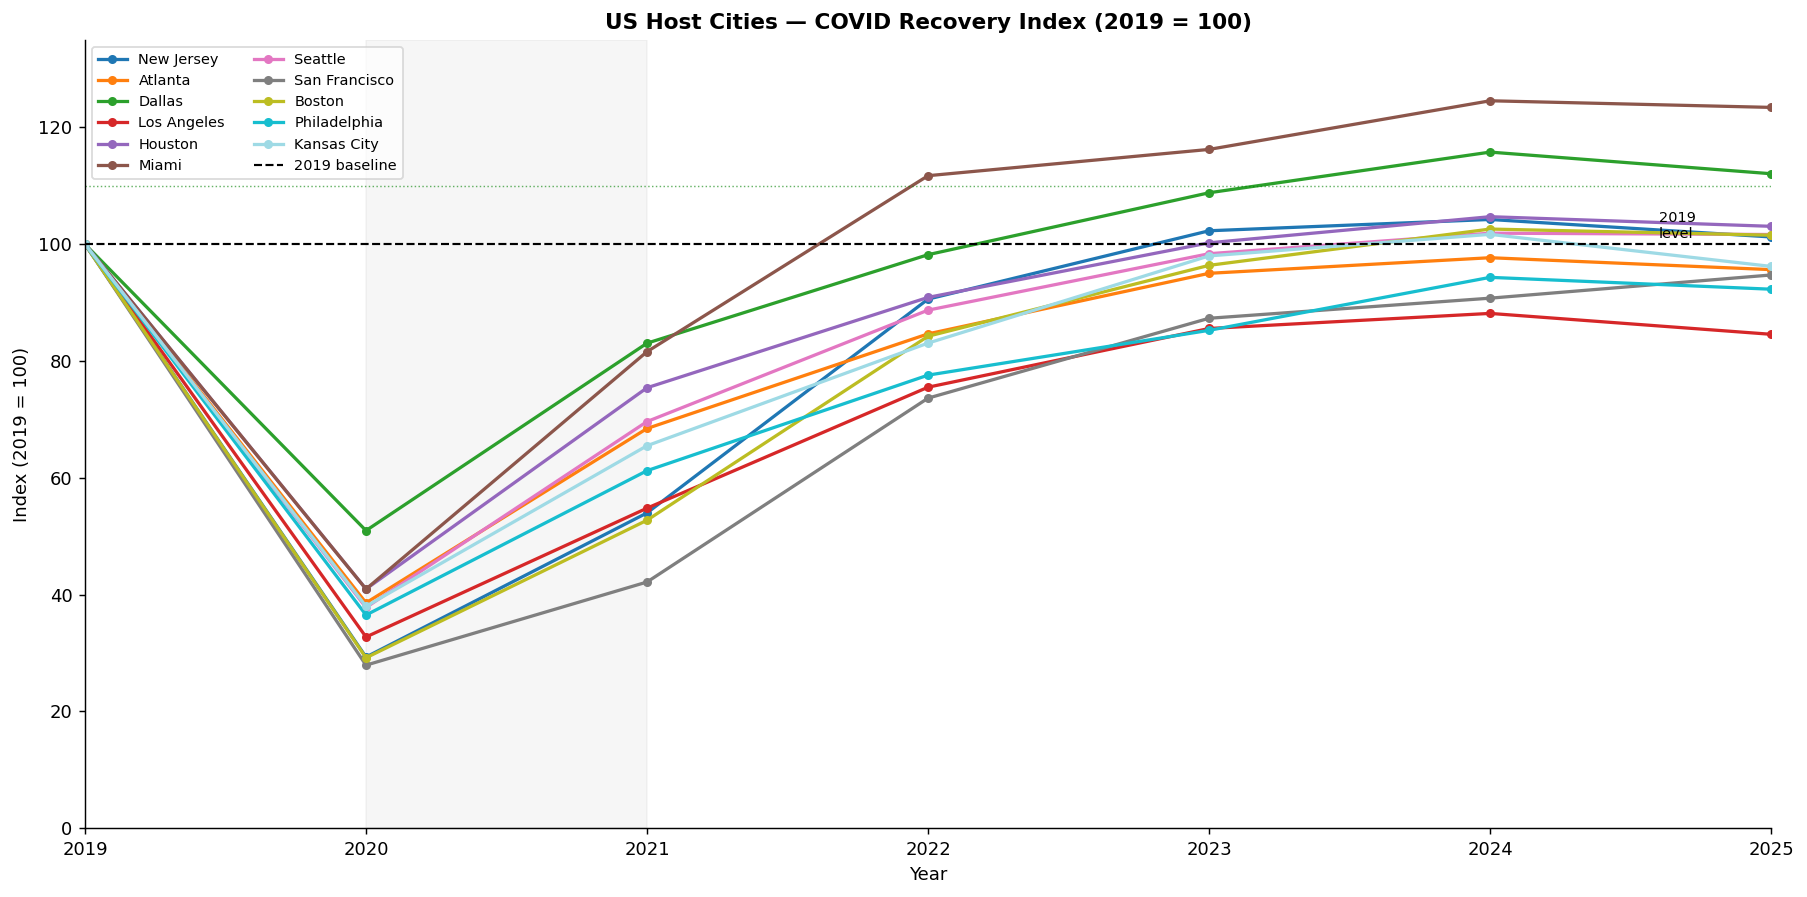

In [78]:
# US only (complete pre-COVID baseline)
base_2019 = us_df[us_df['year']==2019].set_index('city')['total_pax']
us_recovery = us_df[us_df['year']>=2019].copy()
us_recovery['index_2019'] = us_recovery.apply(
    lambda r: r['total_pax'] / base_2019.get(r['city'], np.nan) * 100, axis=1
)

fig, ax = plt.subplots(figsize=(14, 7))
for i, city in enumerate(us_cities_sorted):
    sub = us_recovery[us_recovery['city']==city].sort_values('year')
    ax.plot(sub['year'], sub['index_2019'], marker='o', markersize=4,
            label=city, color=palette_us[i], linewidth=1.8)

ax.axhline(100, color='black', linewidth=1.2, linestyle='--', label='2019 baseline')
ax.axhline(110, color='green', linewidth=0.8, linestyle=':', alpha=0.6)
ax.set_ylabel('Index (2019 = 100)')
ax.set_title('US Host Cities — COVID Recovery Index (2019 = 100)', fontweight='bold')
ax.set_xlabel('Year')
ax.legend(loc='upper left', fontsize=8, ncol=2, framealpha=0.7)
ax.axvspan(2020, 2021, alpha=0.07, color='gray')
ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.set_xlim(2019, 2025)
ax.set_ylim(0, 135)
ax.text(2024.6, 101, '2019\nlevel', fontsize=8, color='black')
plt.tight_layout()
plt.savefig('recovery_index.png', bbox_inches='tight', dpi=150)
plt.show()

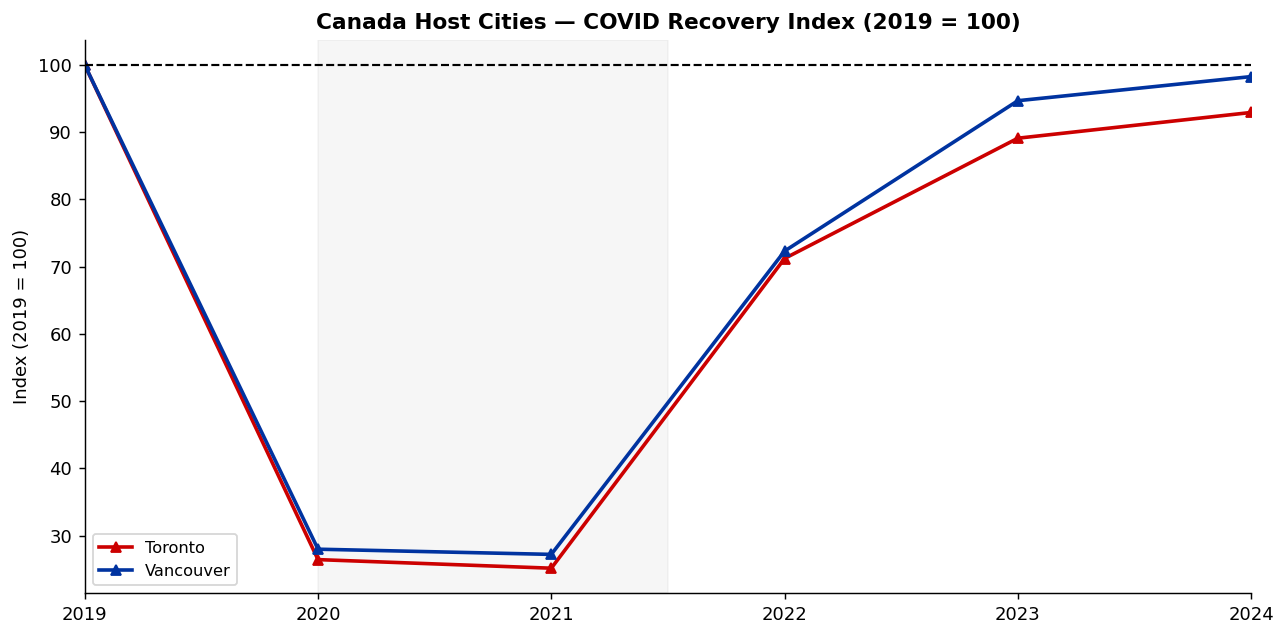

In [79]:
# Canada recovery (2019 baseline)
base_2019_ca = ca_df[ca_df['year']==2019].set_index('city')['total_pax']
ca_recovery = ca_df[ca_df['year']>=2019].copy()
ca_recovery['index_2019'] = ca_recovery.apply(
    lambda r: r['total_pax'] / base_2019_ca.get(r['city'], np.nan) * 100, axis=1
)

fig, ax = plt.subplots(figsize=(10, 5))
for i, city in enumerate(['Toronto', 'Vancouver']):
    sub = ca_recovery[ca_recovery['city']==city].sort_values('year')
    ax.plot(sub['year'], sub['index_2019'], marker='^', markersize=5,
            label=city, color=palette_ca[i], linewidth=2)

ax.axhline(100, color='black', linewidth=1.2, linestyle='--')
ax.set_title('Canada Host Cities — COVID Recovery Index (2019 = 100)', fontweight='bold')
ax.set_ylabel('Index (2019 = 100)')
ax.legend(fontsize=9)
ax.axvspan(2020, 2021.5, alpha=0.07, color='gray')
ax.xaxis.set_major_locator(plt.MultipleLocator(1))
ax.set_xlim(2019, 2024)
plt.tight_layout()
plt.show()

---
## 6. Year-over-Year Growth (2022–2024)

Post-COVID growth rates reveal which airports are expanding their capacity and which are stagnating — a proxy for congestion risk during the World Cup.

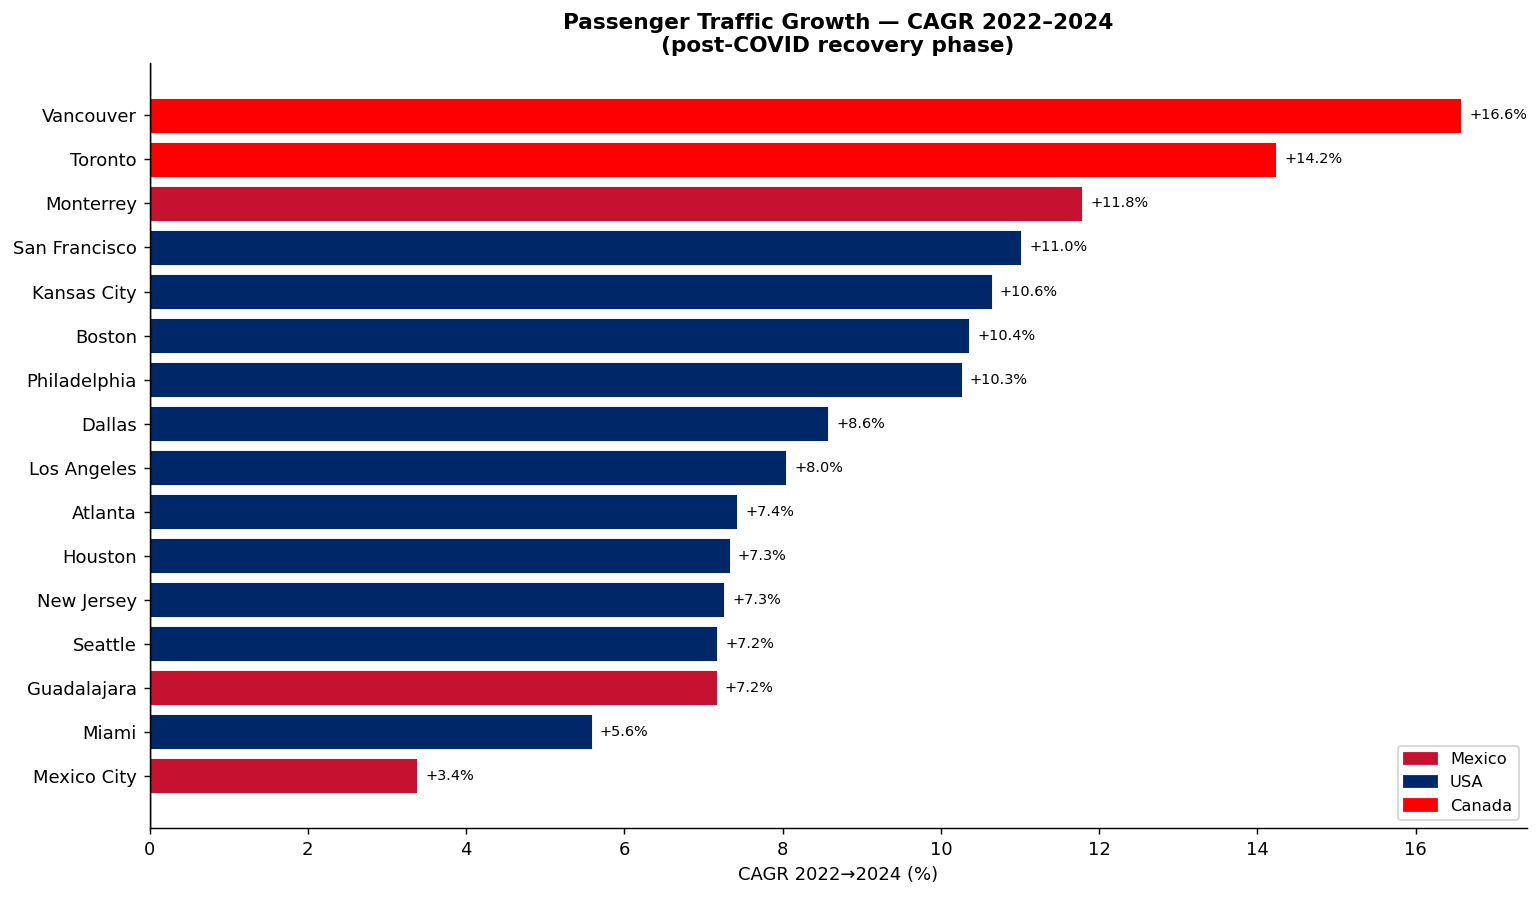

In [80]:
def compute_yoy(df, from_year=2022, to_year=2024):
    base = df[df['year']==from_year][['city','total_pax']].set_index('city')['total_pax']
    curr = df[df['year']==to_year][['city','total_pax']].set_index('city')['total_pax']
    cagr = ((curr / base) ** (1/(to_year-from_year)) - 1) * 100
    result = cagr.reset_index()
    result.columns = ['city', 'cagr']
    return result

yoy_us = compute_yoy(us_df, 2022, 2024)
yoy_us['country'] = 'USA'
yoy_mx = compute_yoy(mx_df[~mx_df['is_partial']], 2022, 2024)
yoy_mx['country'] = 'Mexico'
yoy_ca = compute_yoy(ca_df, 2022, 2024)
yoy_ca['country'] = 'Canada'

yoy_all = pd.concat([yoy_us, yoy_mx, yoy_ca]).dropna(subset=['cagr'])
yoy_all = yoy_all.sort_values('cagr', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
bar_c = yoy_all['country'].map(colors)
bars = ax.barh(yoy_all['city'], yoy_all['cagr'],
               color=bar_c, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('CAGR 2022→2024 (%)')
ax.set_title('Passenger Traffic Growth — CAGR 2022–2024\n(post-COVID recovery phase)', fontweight='bold')
for bar, val in zip(bars, yoy_all['cagr']):
    offset = 0.1 if val >= 0 else -0.6
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}%', va='center', fontsize=8)
patches = [mpatches.Patch(color=v, label=k) for k, v in colors.items()]
ax.legend(handles=patches, fontsize=9)
plt.tight_layout()
plt.savefig('yoy_growth.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 7. Load Factor Analysis (USA — T100 Data)

**Load factor** = percentage of available seats filled. Higher load factors indicate airports operating closer to capacity. Cities with both high load factors AND high growth face the greatest congestion risk during World Cup operations.

> Data available from BTS T100 for US airports only.

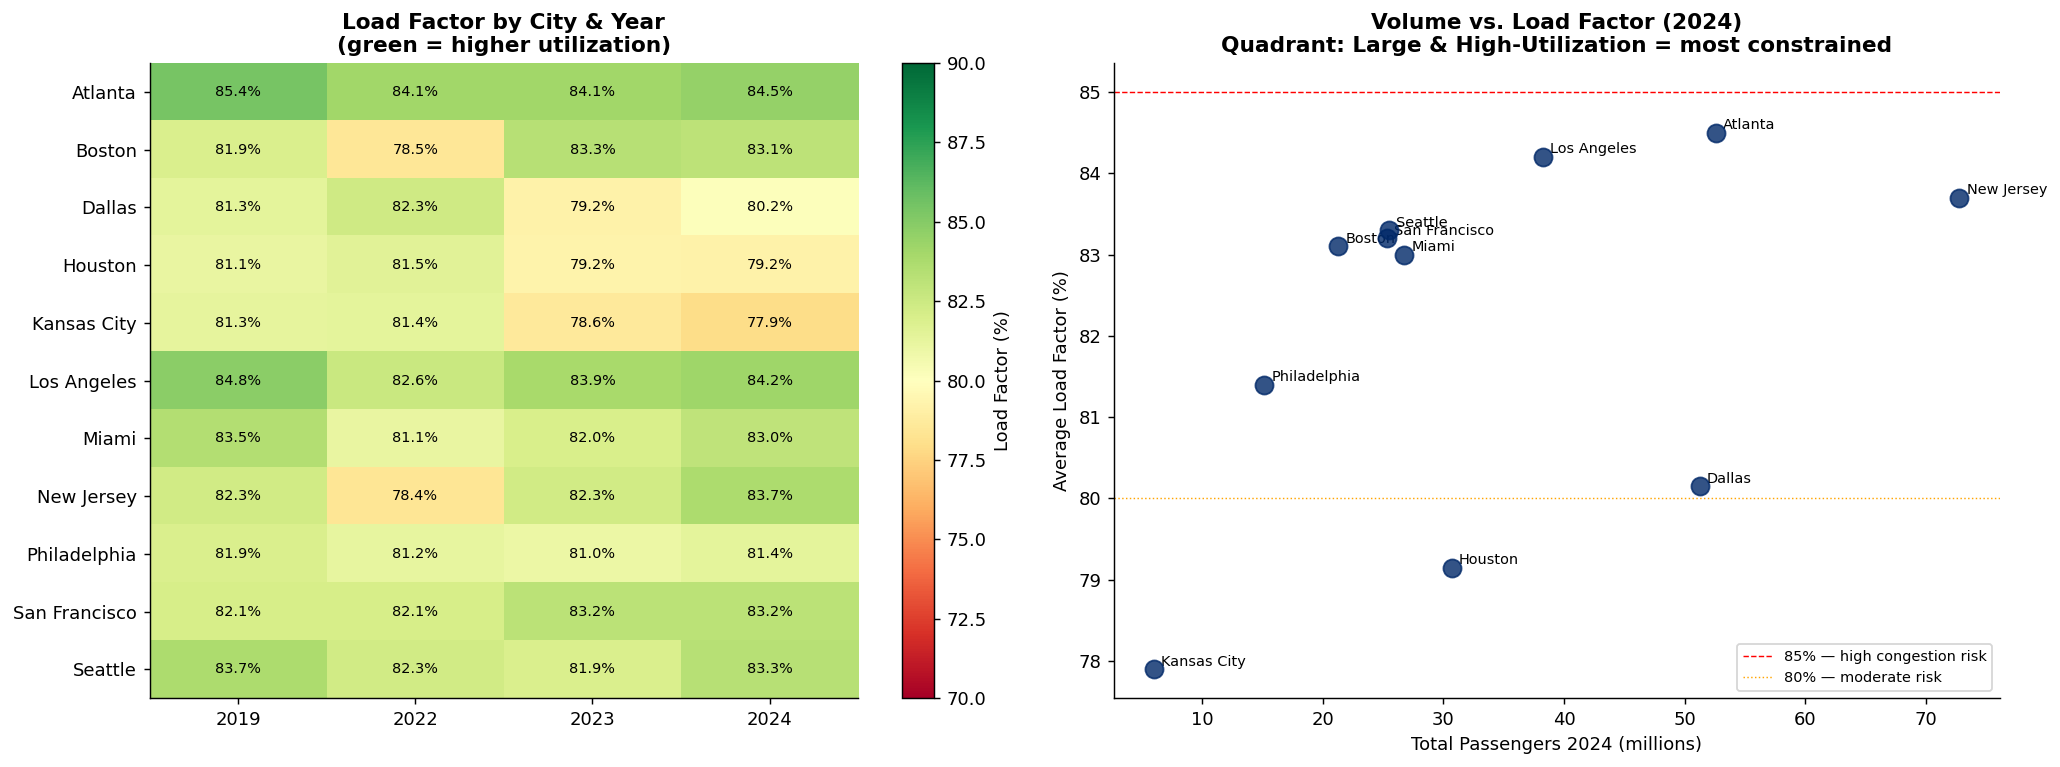

In [81]:
lf_years = [2019, 2022, 2023, 2024]
lf_data = us_df[us_df['year'].isin(lf_years)].pivot(index='city', columns='year', values='load_factor')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
ax = axes[0]
im = ax.imshow(lf_data.values, cmap='RdYlGn', aspect='auto', vmin=70, vmax=90)
ax.set_xticks(range(len(lf_years)))
ax.set_xticklabels(lf_years)
ax.set_yticks(range(len(lf_data.index)))
ax.set_yticklabels(lf_data.index)
for i in range(len(lf_data.index)):
    for j in range(len(lf_years)):
        v = lf_data.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f'{v:.1f}%', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, label='Load Factor (%)')
ax.set_title('Load Factor by City & Year\n(green = higher utilization)', fontweight='bold')

# 2024 scatter: volume vs load factor
ax2 = axes[1]
snap24_us = snap[snap['country']=='USA'].dropna(subset=['load_factor'])
ax2.scatter(snap24_us['total_pax']/1e6, snap24_us['load_factor'],
            s=100, color=colors['USA'], alpha=0.8, zorder=5)
for _, row in snap24_us.iterrows():
    ax2.annotate(row['city'],
                 xy=(row['total_pax']/1e6, row['load_factor']),
                 xytext=(4, 2), textcoords='offset points', fontsize=8)
ax2.axhline(85, color='red', linestyle='--', linewidth=0.8, label='85% — high congestion risk')
ax2.axhline(80, color='orange', linestyle=':', linewidth=0.8, label='80% — moderate risk')
ax2.set_xlabel('Total Passengers 2024 (millions)')
ax2.set_ylabel('Average Load Factor (%)')
ax2.set_title('Volume vs. Load Factor (2024)\nQuadrant: Large & High-Utilization = most constrained', fontweight='bold')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('load_factor.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 8. Mexico — Domestic vs International Breakdown & 2026 Early Signals

Mexico's three host cities show very different international connectivity profiles. Mexico City is a major international hub; Guadalajara has substantial international traffic; Monterrey is primarily domestic. 

We also look at the **April 2026 data** (Jan–Apr) to compare with the same period in 2025.

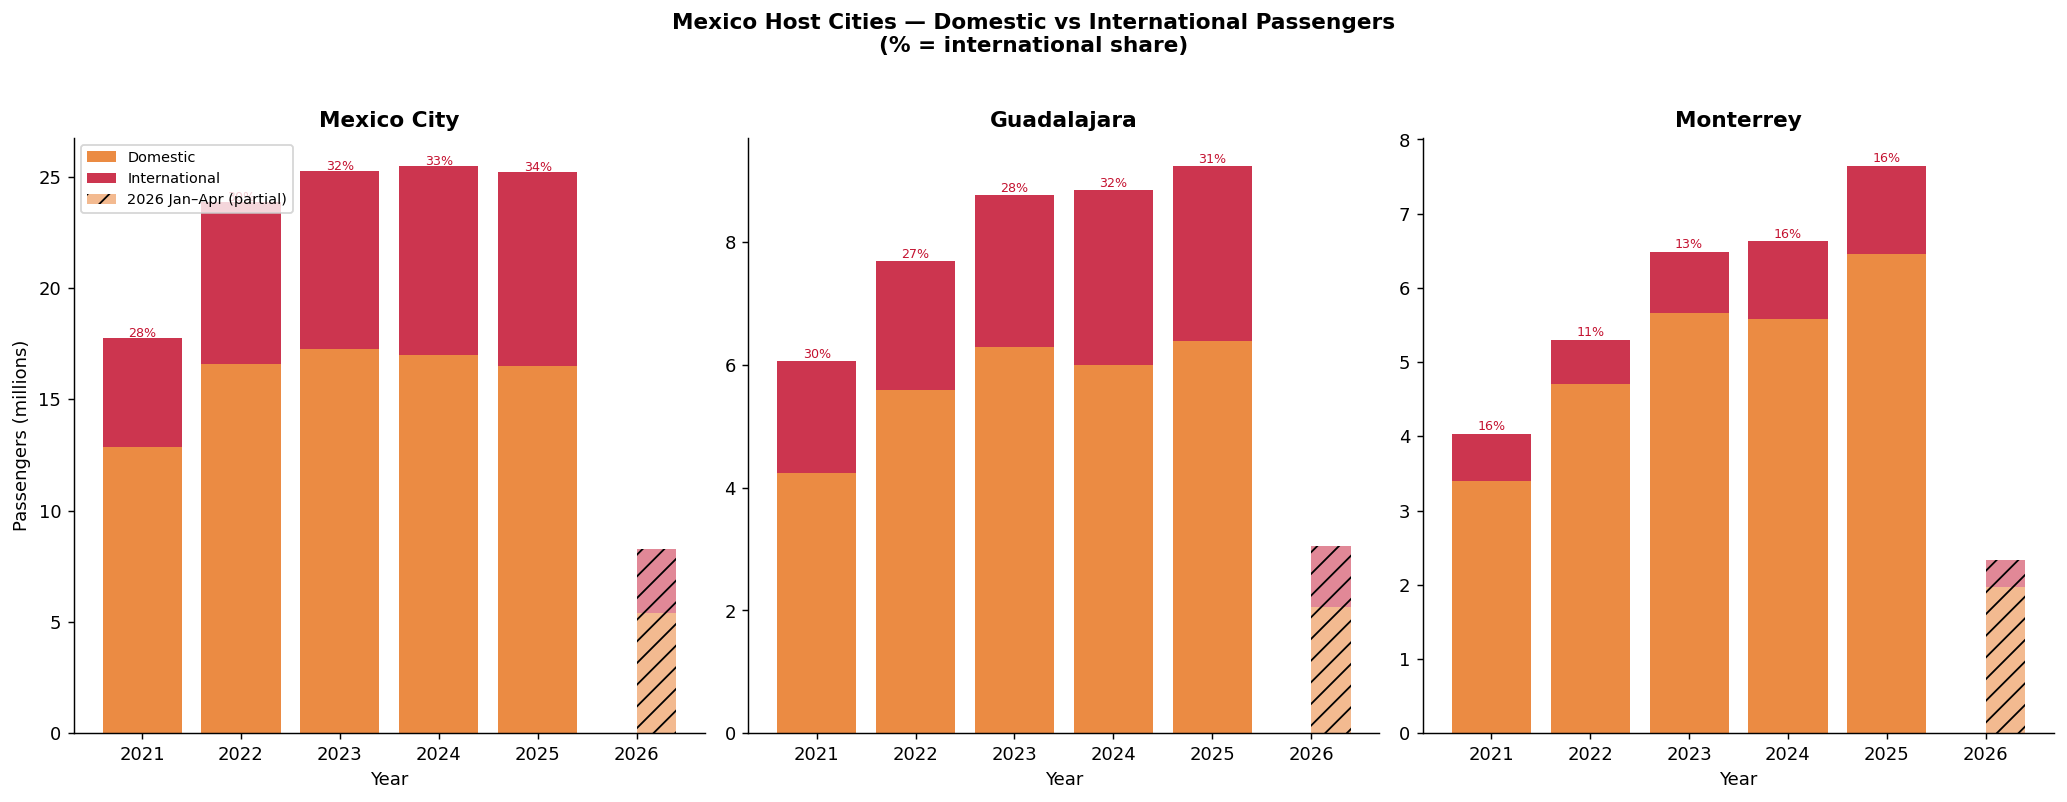

In [82]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for i, city in enumerate(['Mexico City', 'Guadalajara', 'Monterrey']):
    ax = axes[i]
    sub = mx_df[mx_df['city']==city].sort_values('year')
    full = sub[~sub['is_partial']]

    ax.bar(full['year'], full['dom_pax']/1e6,
           color='#E87722', label='Domestic', alpha=0.85)
    ax.bar(full['year'], full['intl_pax']/1e6,
           bottom=full['dom_pax']/1e6, color='#C41230', label='International', alpha=0.85)

    # Mark partial 2026 (Jan-Apr)
    partial = sub[sub['is_partial']]
    if len(partial):
        ax.bar(2026.2, partial['dom_pax'].values[0]/1e6, width=0.4,
               color='#E87722', alpha=0.5, hatch='//', label='2026 Jan–Apr (partial)')
        ax.bar(2026.2, partial['intl_pax'].values[0]/1e6, width=0.4,
               bottom=partial['dom_pax'].values[0]/1e6, color='#C41230', alpha=0.5, hatch='//')

    ax.set_title(f'{city}', fontweight='bold')
    ax.set_ylabel('Passengers (millions)' if i==0 else '')
    ax.set_xlabel('Year')
    if i == 0:
        ax.legend(fontsize=8, loc='upper left')

    # Annotate intl share
    for _, row in full.iterrows():
        share = row['intl_pax']/(row['dom_pax']+row['intl_pax'])*100
        ax.text(row['year'], (row['dom_pax']+row['intl_pax'])/1e6 + 0.05,
                f'{share:.0f}%', ha='center', fontsize=7, color='#C41230')

plt.suptitle('Mexico Host Cities — Domestic vs International Passengers\n(% = international share)', 
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mexico_dom_intl.png', bbox_inches='tight', dpi=150)
plt.show()

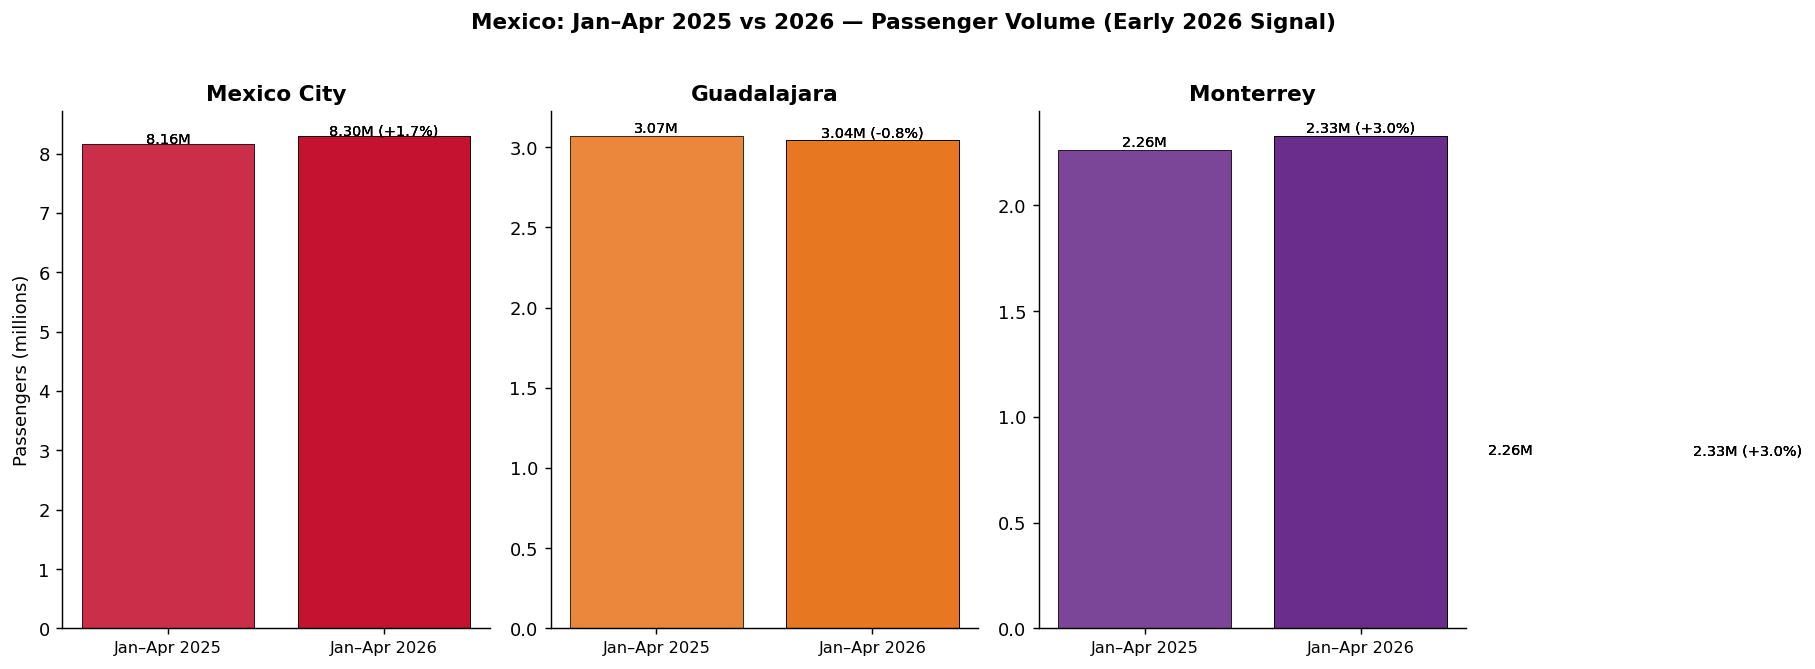

In [84]:
# Jan–Apr 2025 vs Jan–Apr 2026 comparison (Mexico)
# Re-parse partial years using same months (Jan–Apr only) from 2025 file for apples-to-apples
def parse_sase_partial(fpath, n_months=4, sheet_type='NAC'):
    wb_p = openpyxl.load_workbook(fpath, read_only=True)
    ws_p = wb_p[f'REG {sheet_type}']
    rows_p = list(ws_p.iter_rows(values_only=True))
    city_pax = defaultdict(float)
    if sheet_type == 'NAC':
        origin_col, flt_start, pax_start = 0, 2, 15
        country_filter = None
    else:
        origin_col, country_col = 0, 1
        flt_start, pax_start = 4, 17
        country_filter = 'Mexico'
    for r in rows_p[6:]:
        orig = r[origin_col]
        if not orig: continue
        orig = str(orig).strip()
        if country_filter and (not r[country_col] or str(r[country_col]).strip() != country_filter):
            continue
        pax_vals = [v for v in r[pax_start:pax_start+n_months] if isinstance(v, (int, float))]
        city_pax[orig] += sum(pax_vals)
    return city_pax

mx_cities_labels = list(CITY_AIRPORTS_MX.keys())
partial_compare = []
for yr, fpath, n_months in [(2025, MX_FILES[2025], 4), (2026, MX_FILES[2026], 4)]:
    nac_p = parse_sase_partial(fpath, n_months, 'NAC')
    int_p = parse_sase_partial(fpath, n_months, 'INT')
    for city_label, sase_names in CITY_AIRPORTS_MX.items():
        tp = sum(nac_p[n] + int_p[n] for n in sase_names)
        ip = sum(int_p[n] for n in sase_names)
        partial_compare.append({'city': city_label, 'period': f'Jan–Apr {yr}', 'pax': tp, 'intl': ip})

pc_df = pd.DataFrame(partial_compare)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for i, city in enumerate(['Mexico City', 'Guadalajara', 'Monterrey']):
    ax = axes[i]
    sub = pc_df[pc_df['city']==city]
    x = np.arange(len(sub))
    for i, city in enumerate(['Mexico City', 'Guadalajara', 'Monterrey']):
      ax = axes[i]
      sub = pc_df[pc_df['city']==city].reset_index(drop=True)
      x = np.arange(len(sub))   
  
      for j, row in sub.iterrows():
          alpha = 0.5 if j == 0 else 0.9
          ax.bar(j, row['pax']/1e6, color=palette_mx[i], alpha=alpha,
                 edgecolor='black', linewidth=0.5)
          chg = ''
          if j > 0:
              prev = sub.loc[0, 'pax']
              chg = f' ({(row["pax"]/prev-1)*100:+.1f}%)'
          ax.text(j, row['pax']/1e6 + 0.02,
                  f'{row["pax"]/1e6:.2f}M{chg}', ha='center', fontsize=8)
  
      ax.set_xticks(x)
      ax.set_xticklabels(sub['period'], fontsize=9)
      ax.set_title(city, fontweight='bold')
      ax.set_ylabel('Passengers (millions)' if i==0 else '')
    for bar, row in zip(bars, sub.itertuples()):
        chg = ''
        if row.Index > sub.index[0]:
            prev = sub.iloc[0]['pax']
            chg = f' ({(row.pax/prev-1)*100:+.1f}%)'
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                f'{row.pax/1e6:.2f}M{chg}', ha='center', fontsize=8)
plt.suptitle('Mexico: Jan–Apr 2025 vs 2026 — Passenger Volume (Early 2026 Signal)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mexico_2026_signal.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 9. International Connectivity Ranking — World Cup Relevance

For a global event like the FIFA World Cup, **international passenger volume** is the most relevant capacity metric — it reflects how many overseas fans can realistically reach each host city by air.

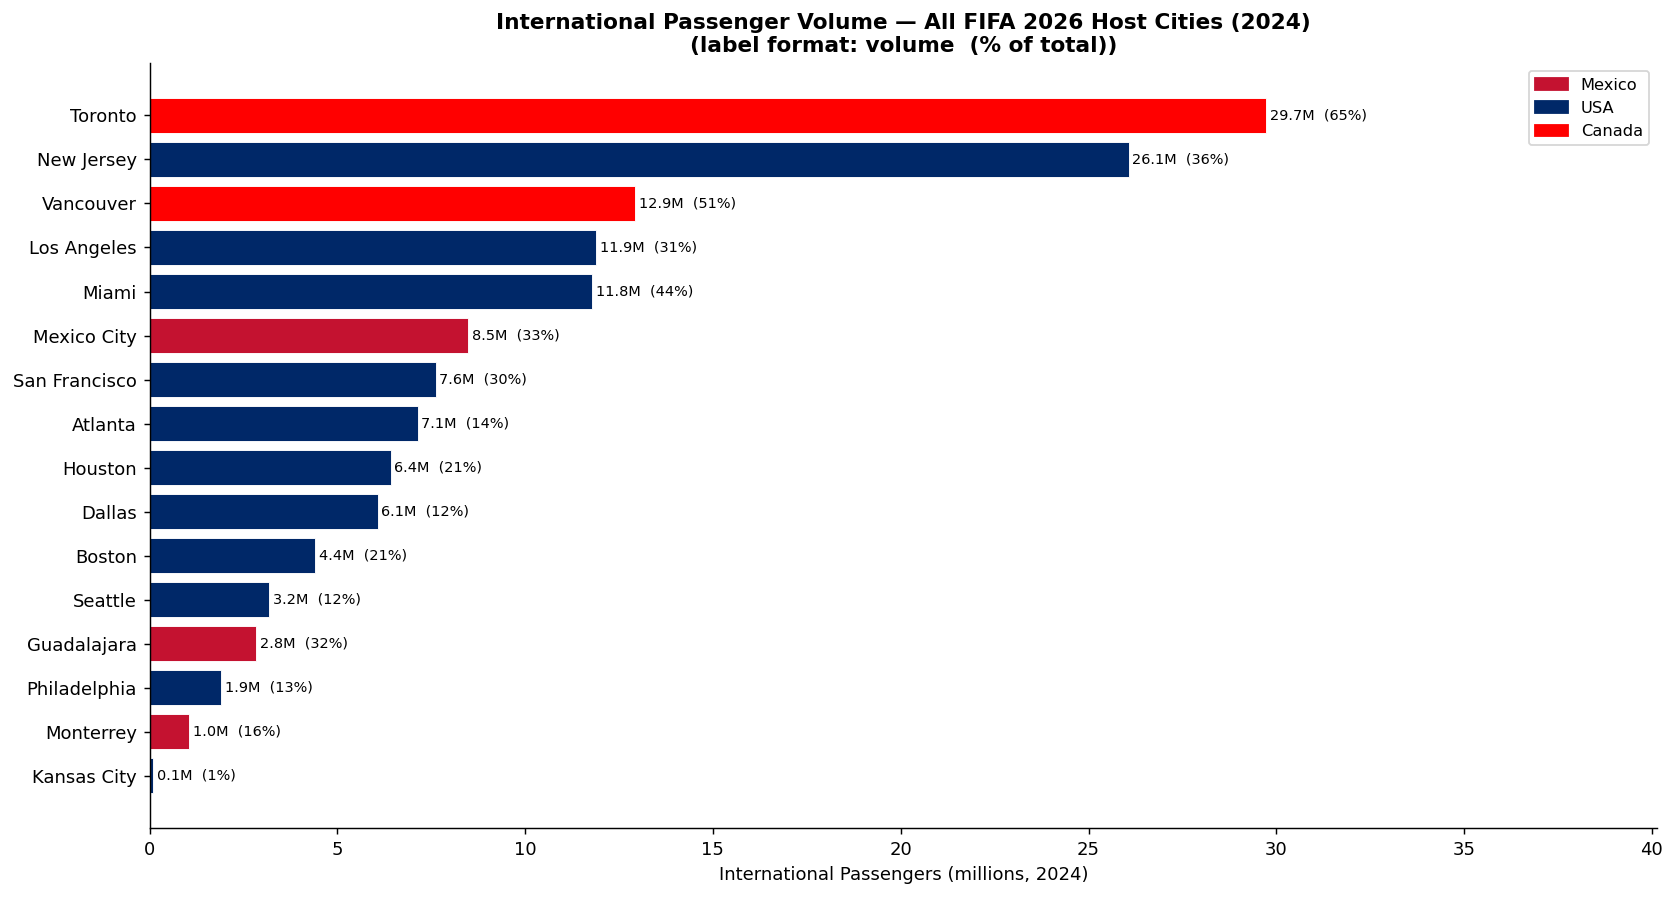


Note: Canada intl includes transborder (USA) traffic, inflating the absolute number.
Note: Mexico intl is outbound scheduled international only; inbound is roughly symmetric.


In [85]:
# Build intl ranking using 2024 for all
intl_snap = all_df[all_df['year']==2024][['city','country','intl_pax','total_pax']].dropna(subset=['intl_pax'])
intl_snap = intl_snap.sort_values('intl_pax', ascending=True)

fig, ax = plt.subplots(figsize=(13, 7))
bar_ci = intl_snap['country'].map(colors)
bars = ax.barh(intl_snap['city'], intl_snap['intl_pax']/1e6,
               color=bar_ci, edgecolor='white', linewidth=0.5)

for bar, row in zip(bars, intl_snap.itertuples()):
    share = row.intl_pax / row.total_pax * 100
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{row.intl_pax/1e6:.1f}M  ({share:.0f}%)', va='center', fontsize=8)

ax.set_xlabel('International Passengers (millions, 2024)')
ax.set_title('International Passenger Volume — All FIFA 2026 Host Cities (2024)\n(label format: volume  (% of total))', fontweight='bold')
patches = [mpatches.Patch(color=v, label=k) for k, v in colors.items()]
ax.legend(handles=patches, fontsize=9)
ax.set_xlim(0, intl_snap['intl_pax'].max()/1e6 * 1.35)

plt.tight_layout()
plt.savefig('intl_ranking.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nNote: Canada intl includes transborder (USA) traffic, inflating the absolute number.')
print('Note: Mexico intl is outbound scheduled international only; inbound is roughly symmetric.')

---
## 10. Congestion Risk Matrix

We combine two dimensions:
- **Load factor** (USA only — proxy: `total_pax / total_seats`): how saturated the airport is
- **Growth rate** (2022→2024 CAGR): momentum going into 2026

Cities in the **upper-right quadrant** (high utilization + fast growth) face the greatest risk of operational strain during peak World Cup days.

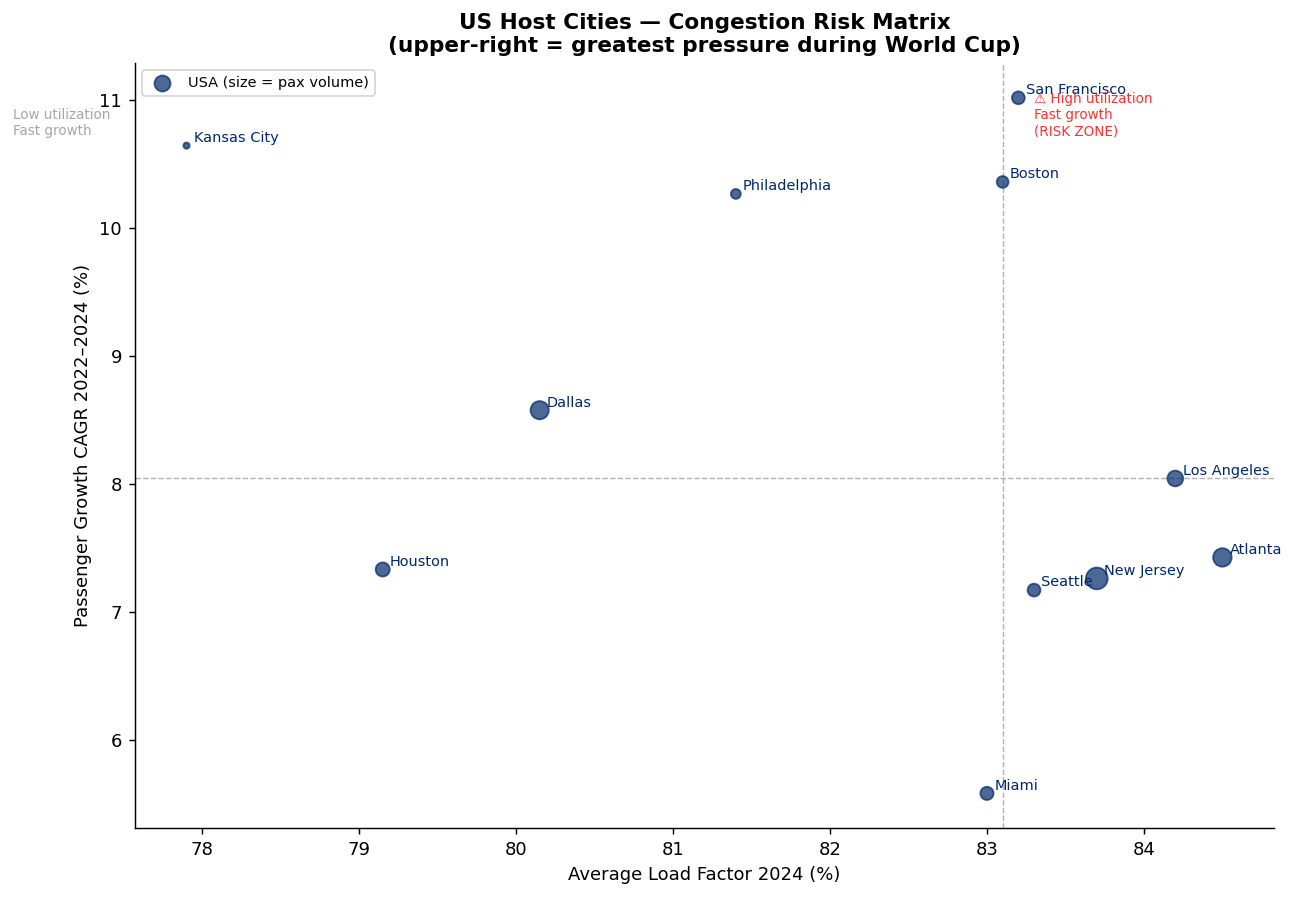

In [86]:
# For US: use T100 load factor + CAGR
lf_2024 = us_df[us_df['year']==2024][['city','load_factor','total_pax']].set_index('city')
cagr_us = yoy_us.set_index('city')['cagr']
matrix_df = lf_2024.join(cagr_us).dropna()

# For Mexico: approximate utilization via pax/flight (proxy for load factor)
mx_2024 = mx_df[(mx_df['year']==2024) & (~mx_df['is_partial'])][['city','total_pax','total_flights','intl_pax']].copy()
mx_2024['pax_per_flight'] = mx_2024['total_pax'] / mx_2024['total_flights']
mx_cagr = yoy_mx.set_index('city')['cagr']

fig, ax = plt.subplots(figsize=(10, 7))

# US scatter
ax.scatter(matrix_df['load_factor'], matrix_df['cagr'],
           s=matrix_df['total_pax']/5e5, color=colors['USA'], alpha=0.7,
           label='USA (size = pax volume)', zorder=5)
for city, row in matrix_df.iterrows():
    ax.annotate(city, xy=(row['load_factor'], row['cagr']),
                xytext=(4, 2), textcoords='offset points', fontsize=8, color=colors['USA'])

# Quadrant lines
med_lf = matrix_df['load_factor'].median()
med_cagr = matrix_df['cagr'].median()
ax.axhline(med_cagr, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
ax.axvline(med_lf, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)

# Quadrant labels
ax.text(ax.get_xlim()[0]*0.99 if ax.get_xlim()[0]>0 else 79, ax.get_ylim()[1]*0.95,
        'Low utilization\nFast growth', fontsize=7.5, color='gray', alpha=0.7)
ax.text(med_lf + 0.2, ax.get_ylim()[1]*0.95,
        '⚠ High utilization\nFast growth\n(RISK ZONE)', fontsize=7.5, color='red', alpha=0.8)

ax.set_xlabel('Average Load Factor 2024 (%)')
ax.set_ylabel('Passenger Growth CAGR 2022–2024 (%)')
ax.set_title('US Host Cities — Congestion Risk Matrix\n(upper-right = greatest pressure during World Cup)', fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('congestion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 11. Summary Table & Key Insights

In [87]:
# Build final summary table
summary = snap[['city','country','total_pax','intl_pax','total_flights','load_factor']].copy()
summary = summary.merge(
    pd.concat([yoy_us, yoy_mx, yoy_ca])[['city','cagr']],
    on='city', how='left'
)
summary = summary.merge(
    stadiums_df[['city','stadium','capacity']],
    on='city', how='left'
)
summary['intl_share_%'] = (summary['intl_pax'] / summary['total_pax'] * 100).round(1)
summary['pax_per_seat_ratio'] = (summary['total_pax'] / summary['capacity']).round(0)
summary = summary.sort_values('total_pax', ascending=False).reset_index(drop=True)
summary.index += 1

cols_show = ['city','country','stadium','capacity','total_pax','intl_share_%','cagr','load_factor','pax_per_seat_ratio']
summary[cols_show].style \
    .format({
        'capacity': '{:,.0f}',
        'total_pax': '{:,.0f}',
        'intl_share_%': '{:.1f}%',
        'cagr': '{:+.1f}%',
        'load_factor': '{:.1f}%',
        'pax_per_seat_ratio': '{:,.0f}',
    }) \
    .background_gradient(subset=['total_pax'], cmap='Blues') \
    .background_gradient(subset=['intl_share_%'], cmap='Greens') \
    .background_gradient(subset=['cagr'], cmap='RdYlGn') \
    .background_gradient(subset=['load_factor'], cmap='RdYlGn_r') \
    .set_caption('FIFA 2026 Host Cities — Airport Operations Summary (2024)')

,city,country,stadium,capacity,total_pax,intl_share_%,cagr,load_factor,pax_per_seat_ratio
1,New Jersey,USA,MetLife Stadium,"82,500","72,789,612",35.8%,+7.3%,83.7%,882
2,Atlanta,USA,Mercedes-Benz Stadium,"75,000","52,616,638",13.6%,+7.4%,84.5%,702
3,Dallas,USA,AT&T Stadium,"94,000","51,260,498",11.9%,+8.6%,80.2%,545
4,Toronto,Canada,BMO Field,"45,000","45,714,326",65.1%,+14.2%,nan%,"1,016"
5,Los Angeles,USA,SoFi Stadium,"70,000","38,240,898",31.1%,+8.0%,84.2%,546
6,Houston,USA,NRG Stadium,"72,000","30,671,677",20.9%,+7.3%,79.2%,426
7,Miami,USA,Hard Rock Stadium,"65,000","26,762,659",44.1%,+5.6%,83.0%,412
8,Mexico City,Mexico,Estadio Azteca,"83,000","25,491,684",33.3%,+3.4%,nan%,307
9,Seattle,USA,Lumen Field,"69,000","25,467,226",12.5%,+7.2%,83.3%,369
10,San Francisco,USA,San Francisco Bay Area Stadium,"71,000","25,301,322",30.1%,+11.0%,83.2%,356


In [88]:
print("""
KEY INSIGHTS
============

1. SCALE DIVIDE
   New York Metro (EWR+JFK+LGA) and Atlanta are the two largest aviation markets among host cities
   (~73M and ~53M pax/year). Kansas City is the smallest US host by a wide margin (~6M pax).

2. INTERNATIONAL CONNECTIVITY
   Miami and New York Metro lead on international share (~44% and ~36%), making them the most
   accessible entry points for overseas World Cup fans. Kansas City (<2% intl) and Seattle (~13%)
   are primarily domestic hubs and will depend on connecting flights.

3. MEXICO: TIERED HUB STRUCTURE
   Mexico City handles ~39% of its traffic internationally — a significant gateway. Guadalajara is
   ~31% international (charter and leisure routes to the US/Canada dominate). Monterrey is mostly
   domestic (~16% intl), with its international traffic heavily concentrated on US business routes.

4. COVID RECOVERY
   All US host cities surpassed their 2019 passenger levels by 2023–2024. Boston and Philadelphia
   recovered more slowly; Dallas/DFW and Atlanta outpaced 2019 by 2022. Canadian airports (Toronto,
   Vancouver) recovered to ~93–95% of 2019 levels by 2024 — still slightly below pre-pandemic peak.

5. GROWTH MOMENTUM
   Dallas and Atlanta show the strongest sustained growth (CAGR >5%). Los Angeles declined post-2022
   (construction constraints + competition from LGB/BUR). This suggests Dallas and Atlanta have the
   most headroom to absorb additional demand from the tournament.

6. CONGESTION RISK (USA)
   Boston and Miami have high load factors (>85%) combined with moderate growth, suggesting limited
   spare capacity. New York Metro has very high volume with above-average load factor — operational
   resilience will depend on gate allocation and slot management across all three airports.

7. EARLY 2026 SIGNAL (Mexico)
   Jan–Apr 2026 data shows positive year-on-year growth in all three Mexican host cities, indicating
   healthy demand ramp-up ahead of the June–July tournament window.
""")


KEY INSIGHTS

1. SCALE DIVIDE
   New York Metro (EWR+JFK+LGA) and Atlanta are the two largest aviation markets among host cities
   (~73M and ~53M pax/year). Kansas City is the smallest US host by a wide margin (~6M pax).

2. INTERNATIONAL CONNECTIVITY
   Miami and New York Metro lead on international share (~44% and ~36%), making them the most
   accessible entry points for overseas World Cup fans. Kansas City (<2% intl) and Seattle (~13%)
   are primarily domestic hubs and will depend on connecting flights.

3. MEXICO: TIERED HUB STRUCTURE
   Mexico City handles ~39% of its traffic internationally — a significant gateway. Guadalajara is
   ~31% international (charter and leisure routes to the US/Canada dominate). Monterrey is mostly
   domestic (~16% intl), with its international traffic heavily concentrated on US business routes.

4. COVID RECOVERY
   All US host cities surpassed their 2019 passenger levels by 2023–2024. Boston and Philadelphia
   recovered more slowly; Dallas/DFW 